<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [124]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)
from sklearn.metrics import silhouette_score


# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [125]:
# loading the data: Wholesale customers data
dataset = pd.read_csv('..\data\Wholesale customers data.csv')

#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [126]:
#check non if null count for each column matches the number of entries (no missing values)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


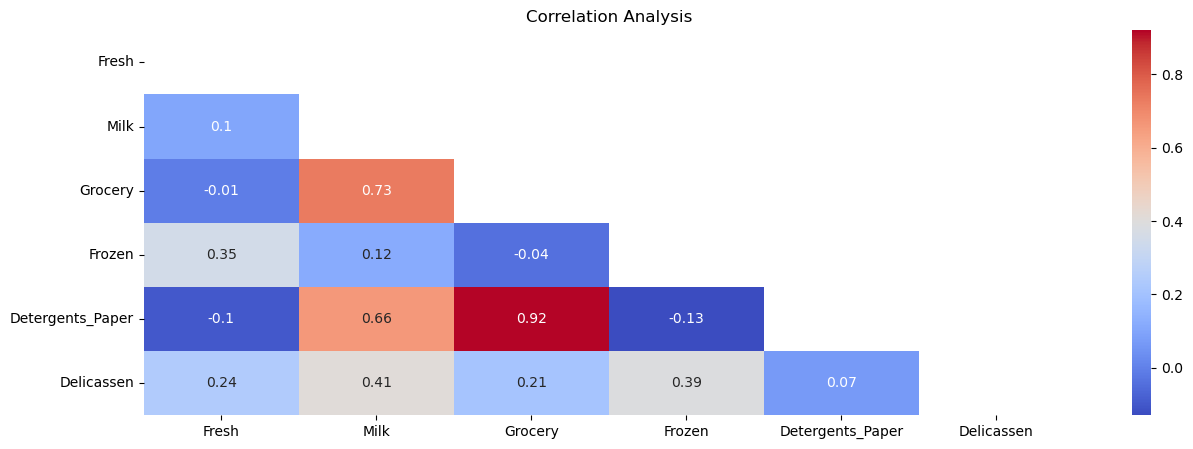

In [127]:
#collinearity check
num = dataset.drop(['Channel','Region'], axis=1)
correlation_matrix = round(num.corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 5))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm")

plt.title("Correlation Analysis")
plt.show()

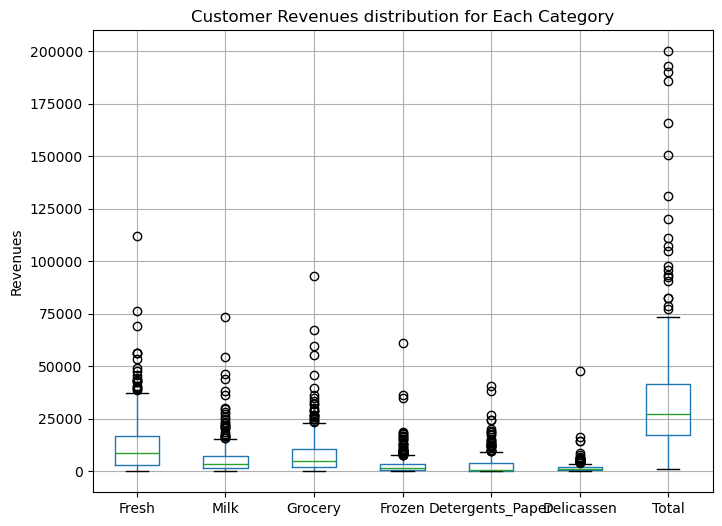

In [128]:
df = dataset.drop(['Channel','Region'], axis=1)
df['Total'] = dataset.sum(axis=1)

# Plotting boxplots for each column
plt.figure(figsize=(8, 6))
df.boxplot()

plt.title('Customer Revenues distribution for Each Category')
plt.ylabel('Revenues')
plt.show()

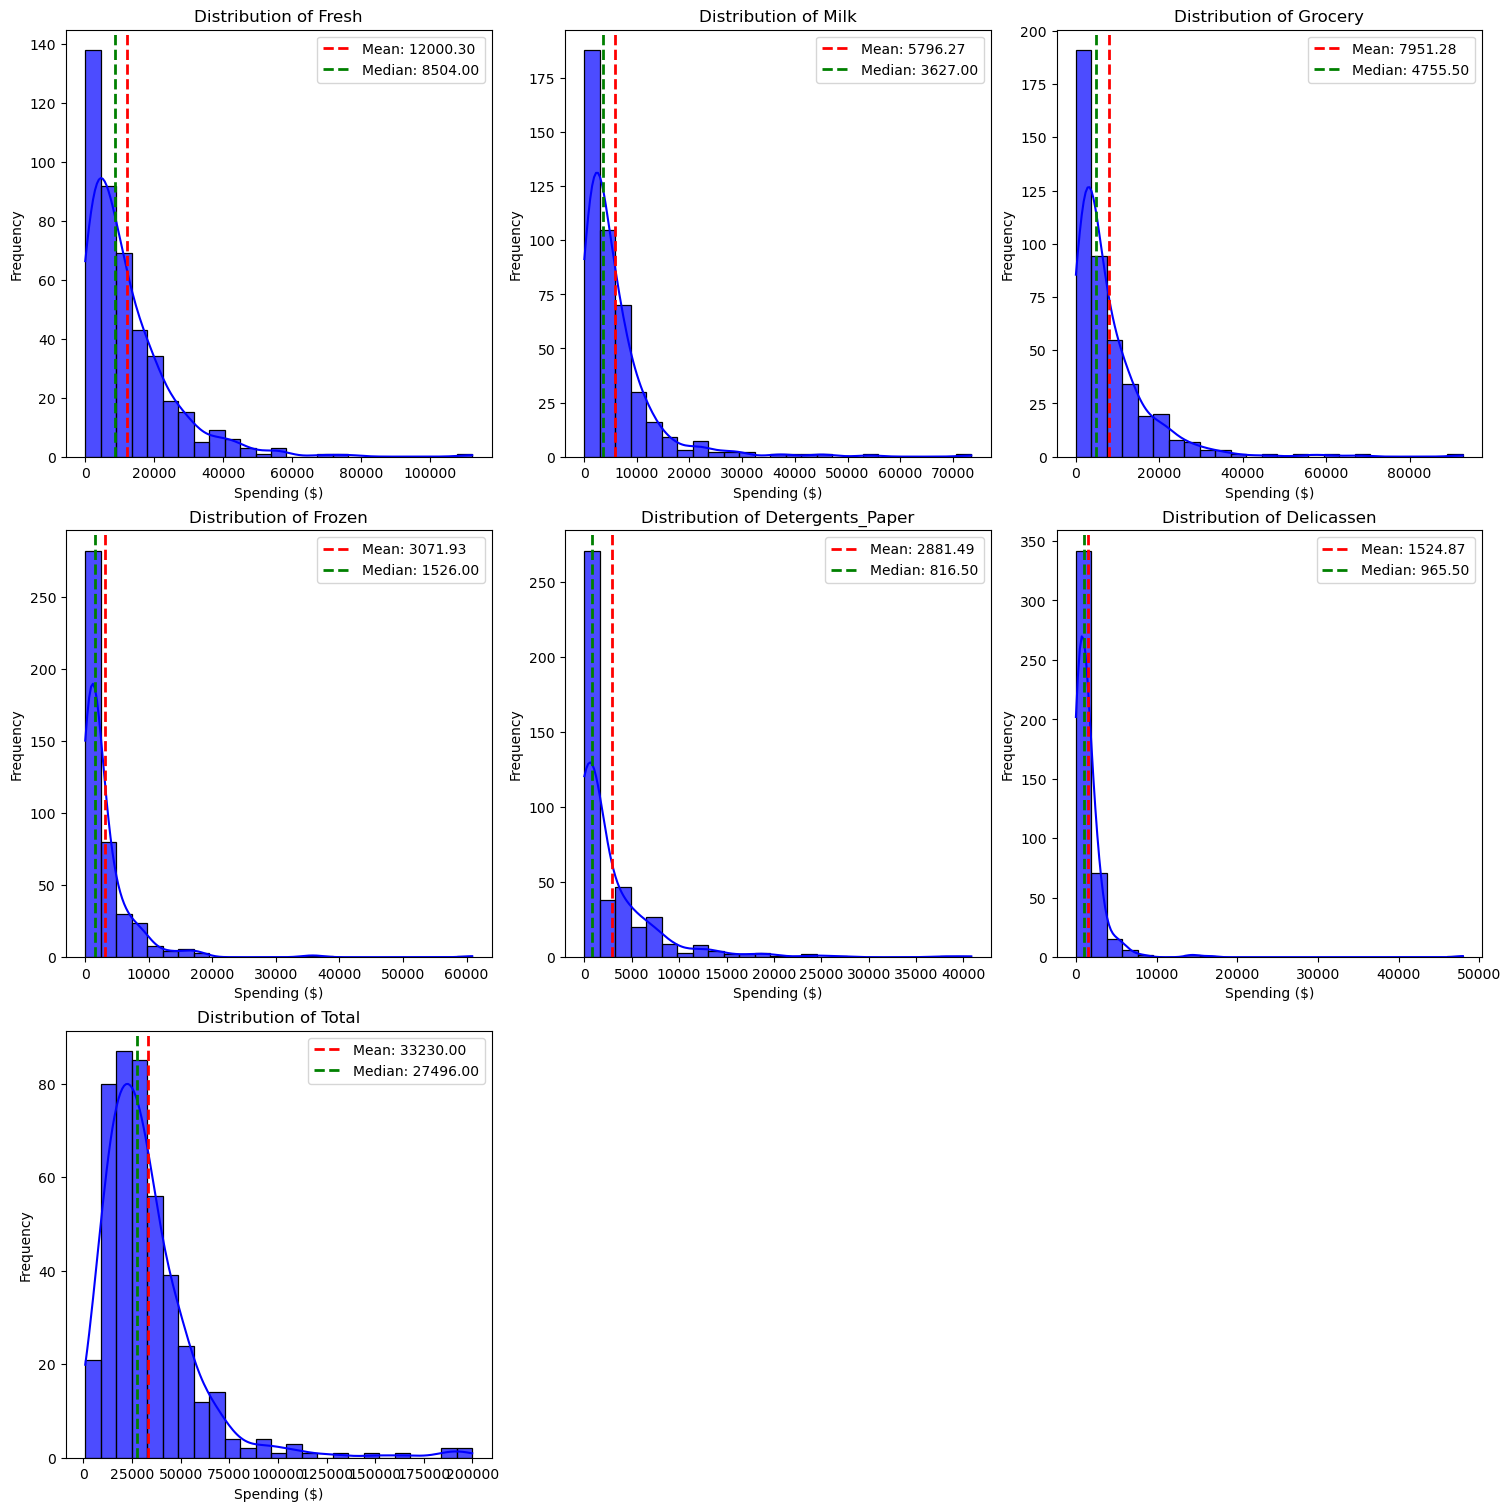

In [129]:



# Determine number of rows and columns
num_columns = len(df.columns)
ncols = 3
nrows = (num_columns + ncols - 1) // ncols  # Ceiling division to determine number of rows

# Plot settings
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows), constrained_layout=True)

# Flatten the axes array for easy iteration if there are more than one row
axes = axes.flatten()

# Iterate over each column to create subplots
for i, column in enumerate(df.columns):
    ax = axes[i]
    customer_spending = df[column]

    sns.histplot(customer_spending, kde=True, color='blue', bins=25, alpha=0.7, ax=ax)
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel('Spending ($)')
    ax.set_ylabel('Frequency')

    # Add mean and median lines
    mean_value = np.mean(customer_spending)
    median_value = np.median(customer_spending)
    ax.axvline(x=mean_value, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
    ax.axvline(x=median_value, color='green', linestyle='--', linewidth=2, label=f'Median: {median_value:.2f}')

    # Add a legend
    ax.legend()

# Hide empty subplots if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.show()
# Additional Insights:
# - The distribution of sample means approximates a normal distribution, as predicted by the CLT.
# - This normal distribution has a mean close to the mean of the original skewed distribution of customer spending.
# - The spread (standard deviation) of this distribution provides insights into the variability of average customer spending.

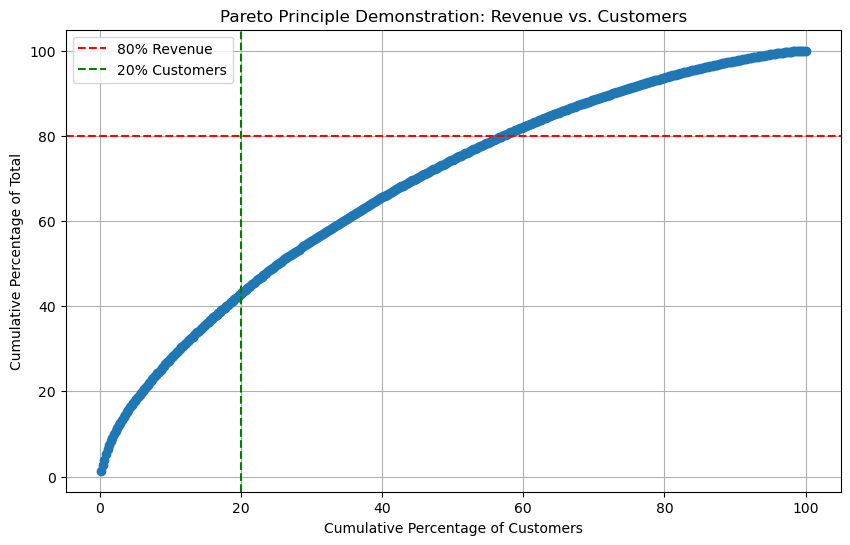

The 20% of the most spending customers makes the 42% of the revenues


C:\Users\ranik\AppData\Local\Temp\ipykernel_35148\2825364643.py:31: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  result = int(filtered_df['CumulativeRevenuePercentage'])


In [130]:
sum_categories = dataset.drop(['Channel','Region'], axis=1).sum(axis=1).reset_index() #first sum the values of numerical columns accross each row (axis = 1)
sum_categories.columns = ['Customer','Revenue'] #rename the columns
# Sort by revenue
df = sum_categories.sort_values(by='Revenue', ascending=False) #order by Revenue

# we want to prove that 80% of effects come from 20% of causes, in our case the effects is the revenue and the causes are the customers
# Calculate cumulative revenue percentage
df['CumulativeRevenue'] = df['Revenue'].cumsum() #the cumulative effect
df['CumulativeRevenuePercentage'] = df['CumulativeRevenue'] / df['Revenue'].sum() * 100 #the cumulative effect percentage

# Calculate cumulative Customers percentage
df['CumulativeCustomerPercentage'] = np.arange(1, len(df) + 1) / len(df) * 100 #the cumulative cause percentage

# Plot cumulative distribution
plt.figure(figsize=(10, 6))
plt.plot(df['CumulativeCustomerPercentage'], df['CumulativeRevenuePercentage'], marker='o')
plt.axhline(80, color='r', linestyle='--', label='80% Revenue')
plt.axvline(20, color='g', linestyle='--', label='20% Customers')
plt.title('Pareto Principle Demonstration: Revenue vs. Customers')
plt.xlabel('Cumulative Percentage of Customers')
plt.ylabel('Cumulative Percentage of Total')
plt.legend()
plt.grid()
plt.show()

# select the first 20% of customers
condition = (df['CumulativeCustomerPercentage'] == 20)
# filter the dataset where the condition is true
filtered_df = df[condition]
# Select the 'CumulativeRevenuePercentage' column from the filtered results
result = int(filtered_df['CumulativeRevenuePercentage'])
print(f'The 20% of the most spending customers makes the {result}% of the revenues')

1. Overview on the variables:
- FRESH: annual spending (m.u.) on fresh products (Continuous);
- MILK: annual spending (m.u.) on milk products (Continuous);
- GROCERY: annual spending (m.u.)on grocery products (Continuous);
- FROZEN: annual spending (m.u.)on frozen products (Continuous)
- DETERGENTS_PAPER: annual spending (m.u.) on detergents and paper products (Continuous)
- DELICATESSEN: annual spending (m.u.)on and delicatessen products (Continuous);
- CHANNEL: customersâ€™ Channel - Horeca (Hotel/Restaurant/CafÃ@) or Retail channel (Nominal)
- REGION: customersâ€™ Region â€" Lisnon, Oporto or Other (Nominal)

2. Categorical variables
- we can convert the two categorical variables (Channel and Region) through the one hot method

3. Missing values:
- There are no missing values

4. Collinearity analysis:
- Customers that spend more on groceries tend to spend more in detergents and paper products as well and we might think to drop detergents and paper products to optimize the model. A strong correlation is evident also between milk and the categories of detergents and papers and grocery category, perhaps suggesting the specific shopping behavior of the families

5. Outliers:
- the boxplots identify for each category several outliers on the upper limit

6. Skew:
- all the distributions are right skewed

7. About Pareto:
- The pareto principle is not proven since the 20% of the most spending customers count for a bit more than 40% of the revenues

In [131]:
# Your code here:
dataset.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [132]:
# Drop categorical columns — not meaningful for spending-based clustering
customers = dataset.drop(columns=['Channel', 'Region'])

# Remove outliers using the IQR method (1.5 × IQR fence)
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
    return df[mask].copy()

clean_customers = remove_outliers_iqr(customers)

print(f"Original shape: {customers.shape}")
print(f"After outlier removal shape: {clean_customers.shape}")
print(f"Rows removed:{customers.shape[0] - clean_customers.shape[0]}")
display(clean_customers.describe())

Original shape: (440, 6)
After outlier removal shape: (332, 6)
Rows removed:108


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000
mean,9547.397590,4105.180723,5875.614458,1863.048193,1958.975904,1016.602410
std,8161.831206,3363.303146,5038.930756,1707.890373,2347.470292,824.356784
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,2989.750000,1352.500000,2011.500000,582.000000,231.750000,360.750000
50%,7483.500000,3087.000000,3835.500000,1270.500000,715.500000,774.000000
75%,13987.250000,6251.750000,8928.500000,2587.500000,3461.250000,1456.000000
max,37036.000000,14982.000000,22272.000000,7683.000000,8969.000000,3637.000000


**Your comment here**

-  ...
-  ...

In [133]:
dataset.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [134]:

test = dataset[['Channel', 'Region']]
clean_customers = clean_customers.merge(test, left_index= True, right_index=True)
len(clean_customers)


332

In [135]:
clean_customers

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel,Region
0,12669,9656,7561,214,2674,1338,2,3
1,7057,9810,9568,1762,3293,1776,2,3
3,13265,1196,4221,6404,507,1788,1,3
5,9413,8259,5126,666,1795,1451,2,3
6,12126,3199,6975,480,3140,545,2,3
...,...,...,...,...,...,...,...,...
432,21117,1162,4754,269,1328,395,1,3
433,1982,3218,1493,1541,356,1449,1,3
434,16731,3922,7994,688,2371,838,1,3
438,10290,1981,2232,1038,168,2125,1,3


# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [136]:
# Your import here:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler = scaler.fit(clean_customers)
customers_standardized = scaler.transform(clean_customers)
customers_standardized


# Your code here:


array([[ 0.38304079,  1.65289825,  0.33497772, ...,  0.3904653 ,
         1.5794736 ,  0.59009178],
       [-0.30558788,  1.69875568,  0.73387771, ...,  0.92259064,
         1.5794736 ,  0.59009178],
       [ 0.45617384, -0.86628288, -0.32886183, ...,  0.93716941,
        -0.63312233,  0.59009178],
       ...,
       [ 0.88147444, -0.05454674,  0.42103835, ..., -0.21698372,
        -0.63312233,  0.59009178],
       [ 0.09112211, -0.63252908, -0.72418424, ...,  1.34659005,
        -0.63312233,  0.59009178],
       [-0.82954447, -0.71679956, -0.66893053, ..., -1.17189357,
        -0.63312233,  0.59009178]], shape=(332, 8))

# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [137]:
from sklearn.cluster import KMeans

# Your code here:

### Looking to the elbow we can choose 2 like the correct number of clusters

In [138]:
#%pip install kneed

from kneed import KneeLocator
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def find_elbow(data, max_k=10):
    inertia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertia.append(kmeans.inertia_)
    
    knee_locator = KneeLocator(
        range(1, max_k + 1), inertia,
        curve="convex", direction="decreasing"
    )
    optimal_k = knee_locator.knee
    
    plt.plot(range(1, max_k + 1), inertia, marker='o')
    plt.axvline(x=optimal_k, linestyle='--', label=f'Optimal k={optimal_k}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.legend()
    plt.show()
    
    return optimal_k



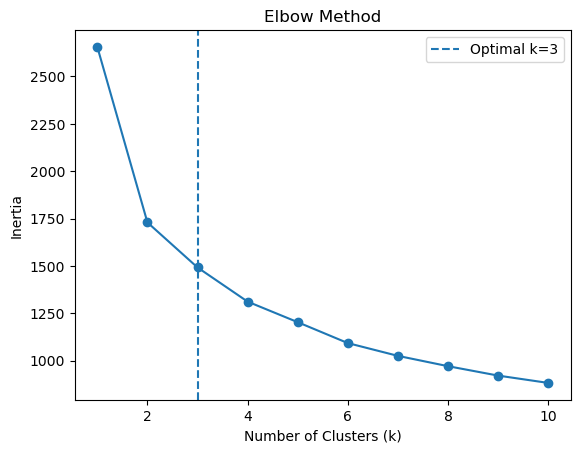

np.int64(3)

In [142]:
find_elbow(customers_standardized)

In [144]:
kmeans_3 = KMeans(n_clusters=3).fit(customers_standardized)

labels = kmeans_3.predict(customers_standardized)

clusters = kmeans_3.labels_.tolist()

In [146]:
customers_standardized

array([[ 0.38304079,  1.65289825,  0.33497772, ...,  0.3904653 ,
         1.5794736 ,  0.59009178],
       [-0.30558788,  1.69875568,  0.73387771, ...,  0.92259064,
         1.5794736 ,  0.59009178],
       [ 0.45617384, -0.86628288, -0.32886183, ...,  0.93716941,
        -0.63312233,  0.59009178],
       ...,
       [ 0.88147444, -0.05454674,  0.42103835, ..., -0.21698372,
        -0.63312233,  0.59009178],
       [ 0.09112211, -0.63252908, -0.72418424, ...,  1.34659005,
        -0.63312233,  0.59009178],
       [-0.82954447, -0.71679956, -0.66893053, ..., -1.17189357,
        -0.63312233,  0.59009178]], shape=(332, 8))

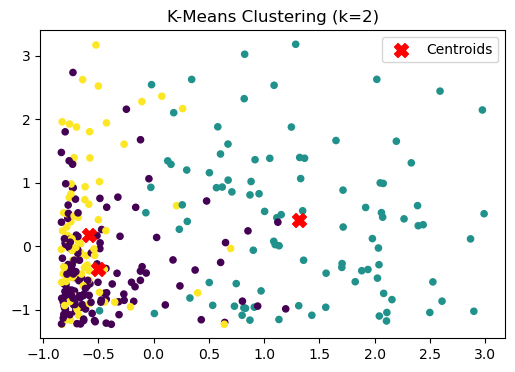

K-Means Silhouette Score: 0.242


In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(customers_standardized[:, 4], customers_standardized[:,5], c=labels, cmap='viridis', s=20)

plt.scatter(kmeans_3.cluster_centers_[:, 4], kmeans_3.cluster_centers_[:, 5], 
            c='red', marker='X', s=100, label='Centroids')

plt.title("K-Means Clustering (k=3)")
plt.legend()
plt.show()

# Silhouette Score
kmeans_score = silhouette_score(customers_standardized, labels)
print(f"K-Means Silhouette Score: {kmeans_score:.3f}")

In [ ]:
kmeans_3.labels_

array([1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,

In [ ]:
clean_customers['Label'] = clusters

Count the values in `labels`.

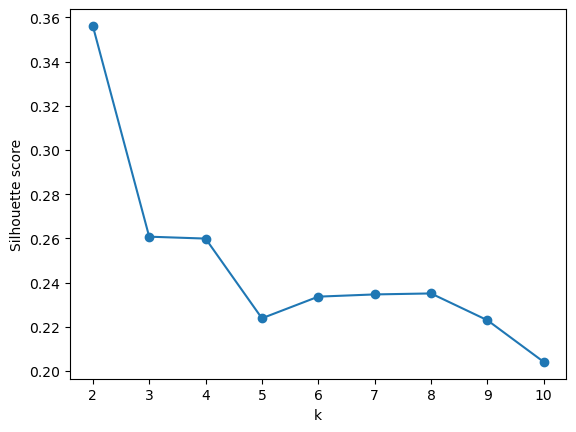

In [155]:
from sklearn.metrics import silhouette_score

silhouettes = []
for k in range(2, 11):  # silhouette needs k>=2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(customers_standardized)
    silhouettes.append(silhouette_score(customers_standardized, labels))

plt.plot(range(2, 11), silhouettes, marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette score')
plt.show()

In [ ]:
# Your code here:
kmeans_3()

AttributeError: 'numpy.ndarray' object has no attribute 'count'

# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

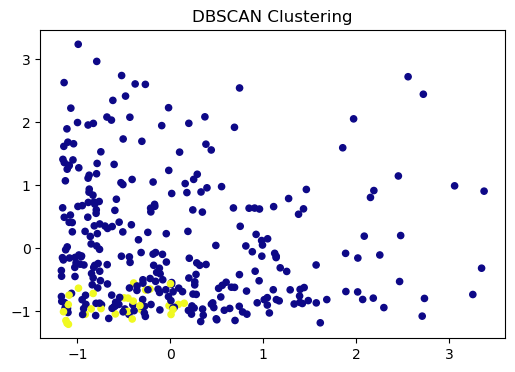

DBSCAN detected less than 2 clusters; silhouette score not applicable.


In [159]:
from sklearn.cluster import DBSCAN 

# Your code here
dbscan = DBSCAN(eps=0.5, min_samples=4)
dbscan_labels = dbscan.fit_predict(customers_standardized)
clean_customers['labels_DBSCAN'] = dbscan_labels

plt.figure(figsize=(6, 4))
plt.scatter(customers_standardized[:, 0], customers_standardized[:, 1], c=dbscan_labels, cmap='plasma', s=20)
plt.title("DBSCAN Clustering")
plt.show()

mask = dbscan_labels != -1  # exclude noise
if len(np.unique(dbscan_labels[mask])) > 1:
    dbscan_score = silhouette_score(customers_standardized[mask], dbscan_labels[mask])
    print(f"DBSCAN Silhouette Score (excluding noise): {dbscan_score:.3f}")
else:
    print("DBSCAN detected less than 2 clusters; silhouette score not applicable.")

Count the values in `labels_DBSCAN`.

In [ ]:
# Your code here


# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [ ]:
def plot(x,y,hue):
    sns.scatterplot(x=x, 
                    y=y,
                    hue=hue)
    plt.title('Detergents Paper vs Milk ')
    return plt.show();

In [ ]:
# Your code here:

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

In [ ]:
# Your code here:

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

In [ ]:
# Your code here:

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [ ]:
# Your code here:

Which algorithm appears to perform better?

**Your observations here**

- 

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

In [ ]:
# Your code here:

**Your comment here**

- 

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

In [ ]:
# Your code here

**Your comment here**

- 